# Challenge Sprint 3 - Probabilidade e Regressao Linear

## Integrantes
| Nome completo | RM |
|---|---|
| [COLOCAR NOME COMPLETO] | [RM xxxxxx] |
| [COLOCAR NOME COMPLETO] | [RM xxxxxx] |
| [COLOCAR NOME COMPLETO] | [RM xxxxxx] |

---

Base: **California Housing** (20.640 registros, salva em `california_housing.csv` pelo script `gerar_dados.py`).

- Variavel de probabilidade: **MedHouseVal** (valor mediano dos imoveis, em 100 mil US$)
- Variaveis da regressao: **MedInc** (renda mediana do bairro) -> **MedHouseVal**


In [2]:
# CHALLENGE SPRINT 3 - Estatistica e Regressao Linear
# Base: California Housing (gerada com gerar_dados.py)
#
# Questoes cobertas:
#   1) Probabilidade acima da mediana (distribuicao normal)
#   2) Probabilidade no intervalo media +/- 2 desvios-padrao
#   3) Regressao linear entre duas variaveis numericas

In [3]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


def classificar_evento(p):
    # probabilidade entre 0 e 1 -> rotulo
    if p < 0.05:
        return "raro"
    elif p < 0.50:
        return "pouco provavel"
    elif p < 0.95:
        return "provavel"
    else:
        return "quase certo"


# ---------------- carrega a base ----------------
TARGET = "MedHouseVal"   # valor mediano dos imoveis (em 100 mil dollars)
X_VAR = "MedInc"         # renda mediana do bairro, usada na regressao
ARQ = "california_housing.csv"

# tenta achar o csv; se nao tiver (ex: colab sem upload), gera na hora pelo sklearn
if os.path.exists(ARQ):
    df = pd.read_csv(ARQ)
    print("base lida do csv:", ARQ)
else:
    from sklearn.datasets import fetch_california_housing
    dados = fetch_california_housing(as_frame=True)
    df = dados.frame
    df.to_csv(ARQ, index=False)
    print("csv nao achei, gerei na hora pelo sklearn")

print("Total de registros:", len(df))
print(df.head())

col = df[TARGET].dropna()  # registro vazio ja era

base lida do csv: california_housing.csv
Total de registros: 20640
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


## Q1 - Probabilidade acima da mediana

In [4]:
# Q1 - Probabilidade acima da mediana


=== Q1: acima da mediana ===
media: 2.0686
desvio padrao: 1.1540
mediana: 1.7970
Z = (mediana - media) / desvio = -0.2353
P(X > mediana) = 0.5930
classificacao: provavel


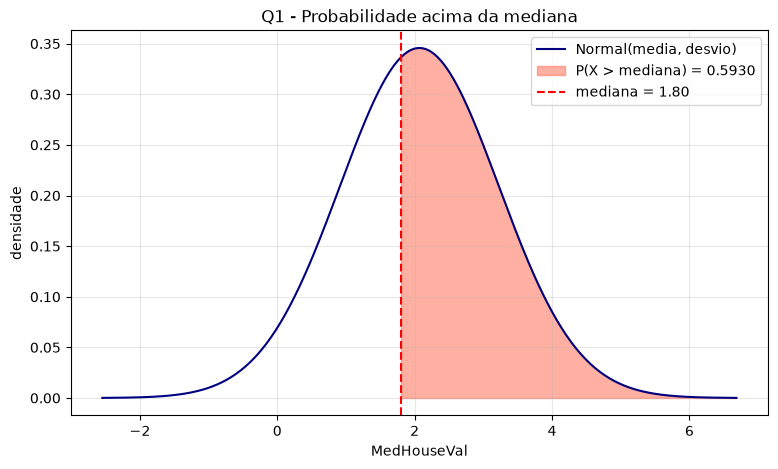

In [5]:
media = col.mean()
desvio = col.std(ddof=1)
mediana = col.median()

print("\n=== Q1: acima da mediana ===")
print(f"media: {media:.4f}")
print(f"desvio padrao: {desvio:.4f}")
print(f"mediana: {mediana:.4f}")

# assume normal com media e desvio da propria amostra
z = (mediana - media) / desvio
prob_acima = 1 - stats.norm.cdf(z)

print(f"Z = (mediana - media) / desvio = {z:.4f}")
print(f"P(X > mediana) = {prob_acima:.4f}")
print("classificacao:", classificar_evento(prob_acima))

# monta a curva normal em cima da media e do desvio da amostra
xs = np.linspace(media - 4 * desvio, media + 4 * desvio, 400)
ys = stats.norm.pdf(xs, media, desvio)

plt.figure(figsize=(9, 5))
plt.plot(xs, ys, color="navy", label="Normal(media, desvio)")
plt.fill_between(xs, ys, where=(xs > mediana), color="tomato", alpha=0.5,
                 label=f"P(X > mediana) = {prob_acima:.4f}")
plt.axvline(mediana, color="red", linestyle="--", label=f"mediana = {mediana:.2f}")
plt.title("Q1 - Probabilidade acima da mediana")
plt.xlabel(TARGET)
plt.ylabel("densidade")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("q1_acima_mediana.png", dpi=120)
plt.show()

## Q2 - Probabilidade no intervalo media +/- 2 desvios

In [6]:
# Q2 - Probabilidade no intervalo media +/- 2 desvios


=== Q2: media +/- 2 desvios ===
media: 2.0686, desvio: 1.1540
intervalo: [-0.2394, 4.3765]
P(intervalo) = 0.9545
classificacao: quase certo


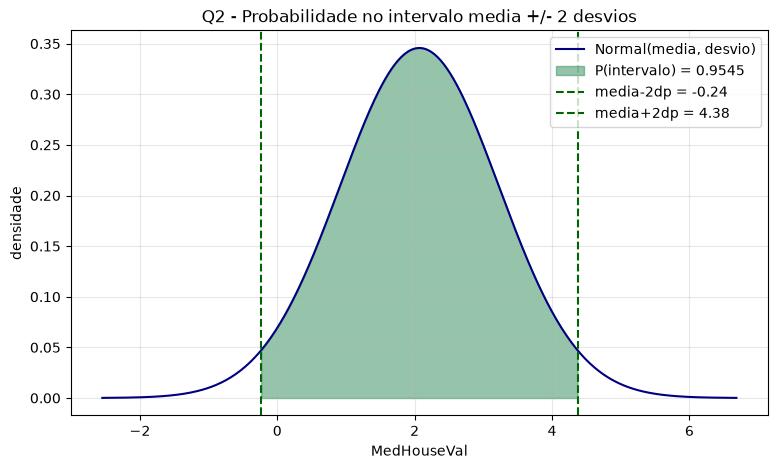

In [7]:
lim_inf = media - 2 * desvio
lim_sup = media + 2 * desvio

p_intervalo = stats.norm.cdf(lim_sup, media, desvio) - stats.norm.cdf(lim_inf, media, desvio)

print("\n=== Q2: media +/- 2 desvios ===")
print(f"media: {media:.4f}, desvio: {desvio:.4f}")
print(f"intervalo: [{lim_inf:.4f}, {lim_sup:.4f}]")
print(f"P(intervalo) = {p_intervalo:.4f}")
print("classificacao:", classificar_evento(p_intervalo))

# mesma curva da Q1, refaz aqui pra essa celula rodar sozinha tambem
xs = np.linspace(media - 4 * desvio, media + 4 * desvio, 400)
ys = stats.norm.pdf(xs, media, desvio)

plt.figure(figsize=(9, 5))
plt.plot(xs, ys, color="navy", label="Normal(media, desvio)")
dentro = (xs >= lim_inf) & (xs <= lim_sup)
plt.fill_between(xs, ys, where=dentro, color="seagreen", alpha=0.5,
                 label=f"P(intervalo) = {p_intervalo:.4f}")
plt.axvline(lim_inf, color="darkgreen", linestyle="--", label=f"media-2dp = {lim_inf:.2f}")
plt.axvline(lim_sup, color="darkgreen", linestyle="--", label=f"media+2dp = {lim_sup:.2f}")
plt.title("Q2 - Probabilidade no intervalo media +/- 2 desvios")
plt.xlabel(TARGET)
plt.ylabel("densidade")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("q2_intervalo.png", dpi=120)
plt.show()

## Q3 - Regressao linear entre renda mediana e valor do imovel

In [8]:
# Q3 - Regressao linear entre renda mediana e valor do imovel


=== Q3: regressao linear ===
Modelo: MedHouseVal = 0.4509 + 0.4179 * MedInc
R2 = 0.4734
Correlacao de Pearson = 0.6881


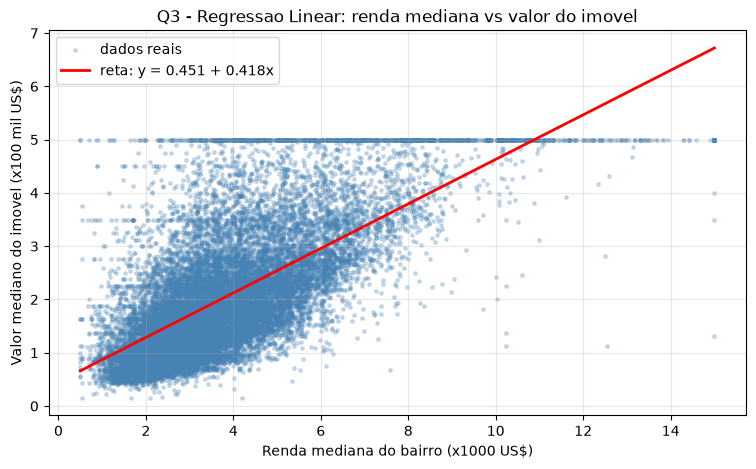


Interpretacao rapida:
b = 0.4179 -> cada ponto a mais na renda mediana (x1000 US$) eleva
   em 0.4179 o valor mediano do imovel (x100 mil US$).
R2 = 0.4734 -> o modelo explica 47.3% da variacao do valor.


In [9]:
X = df[[X_VAR]].dropna()
y = df.loc[X.index, TARGET]

modelo = LinearRegression()
modelo.fit(X, y)

a = modelo.intercept_
b = modelo.coef_[0]

# previsao e metricas
y_pred = modelo.predict(X)
r2 = r2_score(y, y_pred)
correl = df[[X_VAR, TARGET]].dropna().corr().iloc[0, 1]

print("\n=== Q3: regressao linear ===")
print(f"Modelo: {TARGET} = {a:.4f} + {b:.4f} * {X_VAR}")
print(f"R2 = {r2:.4f}")
print(f"Correlacao de Pearson = {correl:.4f}")

# grafico com os pontos + reta ajustada
plt.figure(figsize=(9, 5))
plt.scatter(X, y, s=6, color="steelblue", alpha=0.25, label="dados reais")
xs_reg = np.linspace(X.min().iloc[0], X.max().iloc[0], 200)
xs_df = pd.DataFrame({X_VAR: xs_reg})
plt.plot(xs_reg, modelo.predict(xs_df), color="red", linewidth=2,
         label=f"reta: y = {a:.3f} + {b:.3f}x")
plt.title("Q3 - Regressao Linear: renda mediana vs valor do imovel")
plt.xlabel("Renda mediana do bairro (x1000 US$)")
plt.ylabel("Valor mediano do imovel (x100 mil US$)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("q3_regressao.png", dpi=120)
plt.show()

print("\nInterpretacao rapida:")
print(f"b = {b:.4f} -> cada ponto a mais na renda mediana (x1000 US$) eleva")
print(f"   em {b:.4f} o valor mediano do imovel (x100 mil US$).")
print(f"R2 = {r2:.4f} -> o modelo explica {r2*100:.1f}% da variacao do valor.")